# Кластеризация физической активности по данным c датчиков

### Задача
Построить алгоритм кластеризации, который разделит наблюдения на группы активности на основе данных с IMU-датчиков и пульсометра

### Данные
- исходный датасет `Physical_Activity_Monitoring_unlabeled.csv`
- датасет содержит временные ряды с датчиков, расположенных на разных частях тела
- признаки включают акселерометр, гироскоп, магнитометр, ориентацию, температуру и пульс

### Целевая переменная
Целевая переменная отсутствует, задача относится к обучению без учителя

### Цель
Нужно найти скрытые группы объектов, которые могут соответствовать разным типам активности

### План решения
1. Загрузить данные и изучить структуру
2. Проверить пропуски и аномалии
3. Подготовить признаки
4. Масштабировать данные
5. Подобрать количество кластеров
6. Обучить K-Means
7. Подготовить submission

# Импортируем необходимые библиотеки

In [251]:
# Библиотека для работы с предупреждениями
import warnings
# Библиотеки для работы с данными
import numpy as np
import pandas as pd
# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns
# Предобработка данных
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# Алгоритмы кластеризации
from sklearn.cluster import KMeans
# Метрики для оценки качества кластеризации
from sklearn.metrics import silhouette_score
# Pipeline для удобной сборки этапов обработки
from sklearn.pipeline import Pipeline

# Убираем шум лишних предупреждений
warnings.filterwarnings('ignore')

# Настраиваем отображение таблиц
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# Настраиваем тему графиков
sns.set_theme(
    style='darkgrid',
    context='notebook',
    rc={'figure.figsize': (10, 6)}
)

# Читаем и анализируем датасет

In [252]:
# Загружаем датасет
X = pd.read_csv('data/Physical_Activity_Monitoring_unlabeled.csv')

# Смотрим размер датасета
print(f'X shape: {X.shape}')

X shape: (534601, 53)


In [253]:
# Смотрим первые строки датасета
display(X.head())

# Смотрим типы данных и количество непустых значений
X.info()

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,handGyro3,handMagne1,handMagne2,handMagne3,handOrientation1,handOrientation2,handOrientation3,handOrientation4,chestTemperature,chestAcc16_1,chestAcc16_2,chestAcc16_3,chestAcc6_1,chestAcc6_2,chestAcc6_3,chestGyro1,chestGyro2,chestGyro3,chestMagne1,chestMagne2,chestMagne3,chestOrientation1,chestOrientation2,chestOrientation3,chestOrientation4,ankleTemperature,ankleAcc16_1,ankleAcc16_2,ankleAcc16_3,ankleAcc6_1,ankleAcc6_2,ankleAcc6_3,ankleGyro1,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,-0.000752,-9.99538,7.22910,-32.1399,0.561813,-0.218644,0.359836,0.712095,36.6250,-0.106754,1.66721,9.327970,-0.292054,1.56048,9.749260,-0.019807,-0.034096,0.003963,39.54660,5.58050,-27.96600,0.987675,-0.081231,-0.009229,0.133472,34.1250,-0.458486,-9.074420,-4.47955,-0.318531,-8.899070,-4.13847,0.043954,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,-0.012890,40.45580,-1.19692,-37.5552,0.884964,-0.281047,-0.145657,0.341518,34.6875,0.069756,2.61466,-11.891000,-0.139514,2.40386,-10.968600,0.299329,0.272314,0.249314,17.42950,2.61508,39.32980,0.155581,-0.908072,-0.388069,-0.024528,33.6250,6.035340,2.787170,-2.05542,6.397190,4.930160,-1.31267,-0.319186,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,-0.011507,7.26741,24.43790,-14.3005,0.535655,0.564385,0.371967,-0.506146,37.6250,0.326521,9.81131,0.016322,0.261230,9.78271,0.460448,0.009436,-0.015007,-0.037835,5.63520,-25.82200,-3.77094,0.721119,-0.680477,0.090302,0.093721,33.9375,9.238750,2.809250,-2.56296,9.142330,2.918150,-2.12294,0.065654,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,-1.829000,46.48220,-7.83916,-13.6242,0.648205,0.540984,-0.282560,-0.455332,36.5000,2.127460,8.91873,-8.582920,2.372620,9.73020,-8.650230,0.078109,-0.099471,0.488145,-1.19466,-38.68970,5.28249,0.367155,-0.663333,0.553109,0.345336,34.5625,13.540000,3.082240,2.57328,18.086300,1.822210,2.91851,2.970010,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,-0.032679,3.97764,-22.42320,-20.1775,0.769041,-0.442364,0.232331,0.398638,35.8125,0.648395,9.73894,0.603203,0.519639,9.79662,0.897193,0.003127,-0.015282,-0.061410,4.60037,-25.65500,-3.63808,0.735751,-0.666812,0.086031,0.081430,34.6875,9.551770,-0.494227,-2.77079,9.545500,-0.394571,-2.47767,0.013953,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non-null  float64
 16  ha

## Краткие выводы после первичного анализа

Датасет содержит 534601 строку и 53 признака

Все признаки имеют числовой тип:
- 52 признака имеют тип `float64`
- `subject_id` имеет тип `int64`

В данных есть показания с трех групп датчиков:
- `hand` -> датчики на руке
- `chest` -> датчики на груди
- `ankle` -> датчики на лодыжке

Также есть:
- `timestamp` -> временная метка
- `subject_id` -> идентификатор

В некоторых признаках есть пропуски, которые необходимо будет обработать перед обучением

In [254]:
# Изучим детально пропуски

# Считаем количество пропусков по каждому признаку
missing_values = X.isna().sum()

# Оставляем только признаки с пропусками
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

# Считаем процент пропусков
missing_percent = (missing_values / len(X) * 100).round(2)

# Собираем таблицу для удобного анализа
missing_data = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percent': missing_percent
})

missing_data

,missing_count,missing_percent
handTemperature,4041,0.76
handGyro3,4041,0.76
handAcc16_1,4041,0.76
handOrientation3,4041,0.76
handOrientation2,4041,0.76
handOrientation1,4041,0.76
handMagne3,4041,0.76
handMagne2,4041,0.76
handMagne1,4041,0.76
handOrientation4,4041,0.76


## Краткий вывод по пропускам

В датасете есть пропуски в 51 признаке из 53:
- доля пропусков составляет около 0.76%
- все признаки с пропусками относятся к измерениям датчиков и скорее всего будут полезны для обучения, поэтому удалять их не будем, а обработаем.

Заполним пропуски медианными значениями по каждому признаку
Медиана подходит лучше среднего, так как данные с датчиков могут содержать выбросы

In [255]:
# Заполняем пропуски медианой отдельно для каждого признака

# Создаем копию датасета для дальнейшей обработки
X_clean = X.copy()

# Список колонок с пропусками
cols_with_missing = X_clean.columns[X_clean.isna().sum() > 0]

# Заполняем пропуски медианой по каждому признаку
for col in cols_with_missing:
    X_clean[col] = X_clean[col].fillna(X_clean[col].median())

# Проверяем, остались ли пропуски
missing_after = X_clean.isna().sum().sum()

print(f'Столбцы с пропусками до: {len(cols_with_missing)}')
print(f'Пропущенные значения после: {missing_after}')
# Итоговый размер матрицы
print(f'X_clean shape: {X_clean.shape}')

Столбцы с пропусками до: 51
Пропущенные значения после: 0
X_clean shape: (534601, 53)


## Краткий вывод после обработки пропусков

После обработки в датасете не осталось пропущенных значений, при этом размер данных не изменился
Таким образом, сохранены все наблюдения

In [256]:
# Смотрим стату по признакам
stats_df = X_clean.describe().T

stats_df[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
timestamp,1593.538159,1243.906483,37.660000,475.500000,827.610000,2876.990000,4007.730000
handTemperature,32.454424,1.748587,27.500000,31.312500,32.875000,33.812500,35.250000
handAcc16_1,-4.443074,7.035828,-114.755000,-9.065130,-5.465610,0.367810,60.912600
handAcc16_2,3.240794,7.196689,-82.550900,0.725916,3.089205,5.518940,155.532000
handAcc16_3,4.079963,3.816756,-73.949700,1.617070,4.157125,6.842660,78.480100
handAcc6_1,-4.383900,7.042791,-61.214700,-8.967270,-5.434845,0.413684,34.159400
handAcc6_2,3.217561,6.838792,-61.824200,0.732976,3.127145,5.556420,62.259800
handAcc6_3,4.263655,3.807603,-61.577100,1.806570,4.413625,7.128920,60.843700
handGyro1,-0.008819,1.155719,-19.690500,-0.148494,-0.004439,0.125906,22.960000
handGyro2,0.028614,0.923325,-7.609010,-0.080412,0.004013,0.091399,11.862600


## Краткий вывод

После анализа видно, что все признаки имеют числовой тип и готовы к дальнейшей обработке.

У некоторых признаков есть сильные выбросы, минимальные и максимальные значения отличаются от медианы и квартилей.
Для алгоритма K-Means это важно, так как он основан на расстояниях между объектами и чувствителен к масштабу признаков.

Поэтому перед кластеризацией необходимо будет масштабировать данные.

In [257]:
# Проверяем количество уникальных пользователей
X_clean['subject_id'].value_counts().sort_index()

subject_id
1    69882
2    68740
3    50044
4    63740
5    76793
6    70240
7    62115
8    73047
Name: count, dtype: int64

In [258]:
# Смотрим, сколько всего уникальных subject_id
print(f'Количество уникальных subject_id: {X_clean['subject_id'].nunique()}')

Количество уникальных subject_id: 8


## Краткий вывод

В датасете представлены данные по 8 пользователям.

Признак `subject_id` является идентификатором пользователя, а не показанием датчика, в данной задаче этот признак лучше не использовать при обучении модели, так как он может сместить результат, алгоритм будет учитывать различия между пользователями, а не только признаки движения.

Поэтому `subject_id` сохраним отдельно для анализа, но исключим из матрицы признаков перед кластеризацией.

In [259]:
# Сохраняем subject_id отдельно для возможного анализа результатов
subject_ids = X_clean['subject_id']

# Удаляем subject_id из признаков для кластеризации
X_features = X_clean.drop(columns=['subject_id'])

print(f'X_features shape: {X_features.shape}')

X_features shape: (534601, 52)


# Масштабируем признаки перед кластеризацией

In [260]:
# Создаем объект StandardScaler
scaler = StandardScaler()

# Обучаем scaler на данных и сразу преобразуем признаки
X_scaled = scaler.fit_transform(X_features)

# Преобразуем обратно в DataFrame для удобства анализа
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_features.columns,
    index=X_features.index
)

print(f'X_scaled shape: {X_scaled.shape}')

# Проверяем первые строки после масштабирования
X_scaled.head()

X_scaled shape: (534601, 52)


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,handGyro3,handMagne1,handMagne2,handMagne3,handOrientation1,handOrientation2,handOrientation3,handOrientation4,chestTemperature,chestAcc16_1,chestAcc16_2,chestAcc16_3,chestAcc6_1,chestAcc6_2,chestAcc6_3,chestGyro1,chestGyro2,chestGyro3,chestMagne1,chestMagne2,chestMagne3,chestOrientation1,chestOrientation2,chestOrientation3,chestOrientation4,ankleTemperature,ankleAcc16_1,ankleAcc16_2,ankleAcc16_3,ankleAcc6_1,ankleAcc6_2,ankleAcc6_3,ankleGyro1,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4
0,-1.077886,1.384305,0.759815,0.586093,0.511568,0.765322,0.618266,0.535769,-0.011363,-0.026535,-0.000454,-1.274750,0.802312,-0.429333,-0.191027,-0.604912,1.449864,1.462261,0.502521,-0.398000,-1.243683,1.777097,-0.429051,-1.264229,1.794172,-0.061796,-0.105552,0.092983,1.895306,1.618594,-1.204720,1.277099,1.062247,-0.174775,0.174543,0.582864,-1.287961,-1.079548,-0.444964,-1.379170,-1.120865,-0.537743,0.027415,0.010001,0.013757,0.737324,1.136372,-1.147394,-0.509487,0.786365,1.338156,-0.707776
1,1.655200,-1.546635,0.053120,0.072379,1.100348,-0.225564,0.000756,0.694746,0.108048,-0.438180,-0.007992,0.840386,0.418647,-0.737165,0.902586,-0.780269,-0.151391,0.768646,-0.786137,-0.283054,-1.046698,-2.185863,-0.329224,-1.089322,-2.074853,0.743697,0.477961,0.902570,0.607012,1.468191,1.574197,-1.477008,-1.842157,-1.049883,-0.280641,0.120580,-0.365500,0.444170,0.167250,-0.336554,0.737389,0.292848,-0.352010,-1.034041,0.878232,-0.211915,-0.805266,-0.898181,0.727565,-0.853025,0.297799,-0.536125
2,-0.875290,1.098360,0.346162,-1.784516,-0.866257,0.366389,-1.872691,-0.837792,0.025049,0.014702,-0.007133,-0.551017,1.585887,0.584745,-0.279551,1.595457,1.488291,-0.817943,1.167635,-0.115844,0.449570,0.038008,-0.066964,0.440960,0.059502,0.012013,-0.069201,-0.044937,-0.079992,0.025896,-0.205607,0.394839,-1.042695,0.055140,0.060024,0.409507,0.089551,0.447006,0.039071,0.089629,0.467032,0.054684,0.050088,0.035700,-0.004369,0.515480,0.639777,0.591121,-0.731142,1.374742,0.262592,1.677964
3,0.971193,-0.295624,-1.253461,0.363172,-0.833334,-1.310220,0.394448,-0.899065,1.492102,-0.085675,-1.135790,1.093040,0.116203,0.623189,0.101343,1.529698,-0.585060,-0.722833,0.419382,1.056960,0.263992,-1.568030,1.314798,0.430070,-1.641901,0.185341,-0.230049,1.690642,-0.477823,-0.626739,0.168246,-0.776729,-0.982475,1.124209,0.784904,0.987362,0.700552,0.482074,1.336229,1.478180,0.319769,1.536525,3.084684,-0.213308,-1.722029,0.103991,1.452715,0.369159,0.188631,1.566107,0.008315,1.116458
4,-0.926540,0.597955,0.629512,0.753765,0.083382,0.642935,0.782390,0.146692,0.001628,-0.038986,-0.020281,-0.688939,-0.547857,0.250668,0.510278,-1.233581,1.045965,0.875558,-0.037884,0.093766,0.434523,0.147616,0.102147,0.443845,0.141064,-0.003910,-0.069724,-0.122728,-0.140269,0.034366,-0.200121,0.443269,-0.994695,0.045273,0.024615,1.102933,0.134016,0.022647,-0.013417,0.152221,0.021897,-0.049582,-0.003932,0.005845,-0.002970,0.569341,-0.274929,-0.209193,-0.626844,-1.178430,-0.147386,-0.890807


## Краткий вывод после масштабирования

Признаки были масштабированы с помощью `StandardScaler`, то есть все признаки приведены к единому масштабу.

Это необходимо для кластеризации, потому что алгоритмы вроде `KMeans` используют расстояния между объектами.
Без масштабирования признаки с большими числовыми значениями могли бы сильнее влиять на результат.

# Подбираем количество кластеров методом локтя

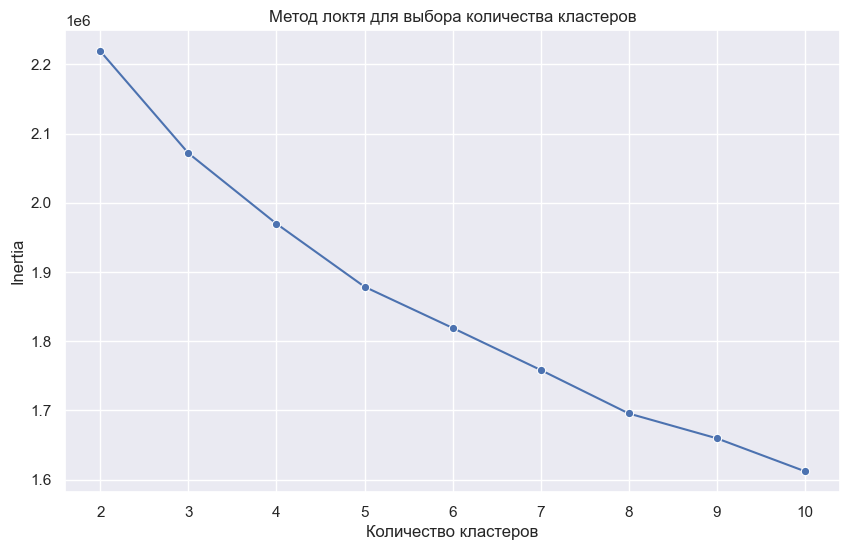

In [261]:
# Берем подвыборку для ускорения расчетов
X_sample = X_scaled.sample(
    n=50000,
    random_state=42
)

# Список количества кластеров, которые будем проверять
cluster_range = range(2, 11)

# Переменная для сохранения значения inertia
inertia_values = []

# Обучаем KMeans для разного количества кластеров
for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_sample)
    inertia_values.append(kmeans.inertia_)

# Строим график метода локтя
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=list(cluster_range),
    y=inertia_values,
    marker='o'
)

plt.title('Метод локтя для выбора количества кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.show()

## Краткий вывод

По методу локтя видно, что значение `inertia` уменьшается при увеличении количества кластеров.

Явно выраженного локтя на графике нет, но после 5 кластеров снижение становится более плавным.
Поэтому для базового решения выберем `n_clusters = 5`.

# Обучаем финальную модель кластеризации

In [262]:
# Выбираем количество кластеров по методу локтя
n_clusters = 5

# Создаем модель KMeans
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

# Обучаем модель и получаем номер кластера для каждой строки
cluster_labels = kmeans.fit_predict(X_scaled)

# Добавляем кластеры в исходный очищенный датасет
X_result = X_clean.copy()
X_result['cluster'] = cluster_labels

# Смотрим размер получившегося датасета
print(f'X_result shape: {X_result.shape}')

# Смотрим распределение объектов по кластерам
X_result['cluster'].value_counts().sort_index()

X_result shape: (534601, 54)


cluster
0    137444
1    122872
2     87909
3    126164
4     60212
Name: count, dtype: int64

## Краткий вывод

После обучения `KMeans` все объекты были распределены по 5 кластерам.

Размеры кластеров:

- кластер 0 -> 137444 об.
- кластер 1 -> 122872 об.
- кластер 2 -> 87909 об.
- кластер 3 -> 126164 об.
- кластер 4 -> 60212 об.

Распределение выглядит адекватно, так как каждый кластер содержит множество наблюдений.
Таки образом, модель не выделила случайные маленькие группы, нашла устойчивые закономерности в данных.

# Пытаемся понять, чем кластеры отличаются друг от друга

In [263]:
# Создаем агрегированные признаки для анализа кластеров

X_analysis = X_result.copy()

# Температурные признаки
temperature_cols = [
    'handTemperature',
    'chestTemperature',
    'ankleTemperature'
]

# Ускорение
acc_cols = [
    col for col in X_analysis.columns
    if 'Acc' in col
]

# Гироскоп
gyro_cols = [
    col for col in X_analysis.columns
    if 'Gyro' in col
]

# Магнитометр
magne_cols = [
    col for col in X_analysis.columns
    if 'Magne' in col
]

# Ориентация
orientation_cols = [
    col for col in X_analysis.columns
    if 'Orientation' in col
]

# Добавляем средние значения по группам датчиков
X_analysis['mean_temperature'] = X_analysis[temperature_cols].mean(axis=1)
X_analysis['mean_acc'] = X_analysis[acc_cols].mean(axis=1)
X_analysis['mean_gyro'] = X_analysis[gyro_cols].mean(axis=1)
X_analysis['mean_magne'] = X_analysis[magne_cols].mean(axis=1)
X_analysis['mean_orientation'] = X_analysis[orientation_cols].mean(axis=1)

# Смотрим первые строки новых агрегированных признаков
X_analysis[
    [
        'cluster',
        'mean_temperature',
        'mean_acc',
        'mean_gyro',
        'mean_magne',
        'mean_orientation'
    ]
].head()

,cluster,mean_temperature,mean_acc,mean_gyro,mean_magne,mean_orientation
0,2,35.208333,1.315952,-0.002216,-1.191376,0.271664
1,0,32.687500,0.611233,0.149445,1.240723,-0.030968
2,1,35.312500,1.051459,0.006305,1.803519,0.250583
3,1,34.333333,1.920775,-0.042901,2.151019,0.242066
4,3,34.666667,3.430455,-0.015391,-8.233186,0.023418


## Создание агрегированных признаков для анализа

Для дальнейшей интерпретации кластеров были созданы дополнительные агрегированные признаки.

Группировка по типам измерений:

- температура
- ускорение
- гироскоп
- магнитометр
- ориентация

Для каждой группы рассчитано среднее значение по строке.
Эти признаки нужны только для анализа полученных кластеров (для понимания, чем один кластер отличается от другого).

Из вывода таблицы видно, что агрегированные признаки успешно добавлены.
Теперь для каждого наблюдения есть обобщенные характеристики движения и состояния датчиков.

## Анализ средних характеристик кластеров

После того как каждому наблюдению был назначен номер кластера, пытаемся понять, чем кластеры отличаются друг от друга.

Сгруппируем данные по `cluster` и посчитаем средние значения агрегированных признаков:

- `mean_temperature` -> средняя температура по датчикам
- `mean_acc` -> среднее ускорение
- `mean_gyro` -> средние значения гироскопа
- `mean_magne` -> средние значения магнитометра
- `mean_orientation` -> средняя ориентация

Таким образом, даем кластерам примерную интерпретацию.

In [264]:
# Считаем средние значения агрегированных признаков по каждому кластеру
cluster_profile = (
    X_analysis
    .groupby('cluster')
    [
        [
            'mean_temperature',
            'mean_acc',
            'mean_gyro',
            'mean_magne',
            'mean_orientation'
        ]
    ]
    .mean()
    .round(3)
    .reset_index()
)

cluster_profile

,cluster,mean_temperature,mean_acc,mean_gyro,mean_magne,mean_orientation
0,0,33.819,1.426,-0.003,-1.419,-0.021
1,1,34.219,1.631,0.020,-6.103,0.191
2,2,33.638,1.582,-0.002,-1.288,0.214
3,3,34.218,2.275,-0.024,-5.318,-0.001
4,4,33.501,2.627,0.028,-15.272,0.239


## Краткий вывод по профилям кластеров

По средним значениям видно, что кластеры отличаются прежде всего показателями движения.

Наиболее заметные различия наблюдаются в признаках:
- `mean_acc` -> среднее ускорение
- `mean_magne` -> магнитометр
- `mean_orientation` -> ориентация тела

Кластеры `3` и `4` имеют самые высокие значения `mean_acc`, их можно связать с более активными движениями.

Кластер `0` имеет более низкое среднее ускорение и почти нулевые значения ориентации и гироскопа. Скорее всего, он соответствует более спокойным состояниям.

Кластер `4` дополнительно выделяется самым низким значением `mean_magne`, поэтому он сильно отличается от остальных по признакам.

Температура между кластерами отличается не очень сильно, поэтому она меньше влияет на разделение наблюдений, чем признаки движения.

In [265]:
# Сортируем кластеры по среднему ускорению
cluster_profile.sort_values('mean_acc', ascending=False)

,cluster,mean_temperature,mean_acc,mean_gyro,mean_magne,mean_orientation
4,4,33.501,2.627,0.028,-15.272,0.239
3,3,34.218,2.275,-0.024,-5.318,-0.001
1,1,34.219,1.631,0.020,-6.103,0.191
2,2,33.638,1.582,-0.002,-1.288,0.214
0,0,33.819,1.426,-0.003,-1.419,-0.021


## Вывод по активности кластеров после сортировки

После сортировки по `mean_acc` отчетливо видно, что кластеры можно упорядочить по уровню активности:

- кластер `4` -> самый высокий уровень движения
- кластер `3` -> также высокая активность
- кластеры `1` и `2` -> средний уровень активности
- кластер `0` -> самый низкий уровень активности

Таким образом, признак `mean_acc` хорошо помогает интерпретировать полученные кластеры.
Скорее всего алгоритм разделил наблюдения по различиям в интенсивности движения.

# Визуализируем наблюдения

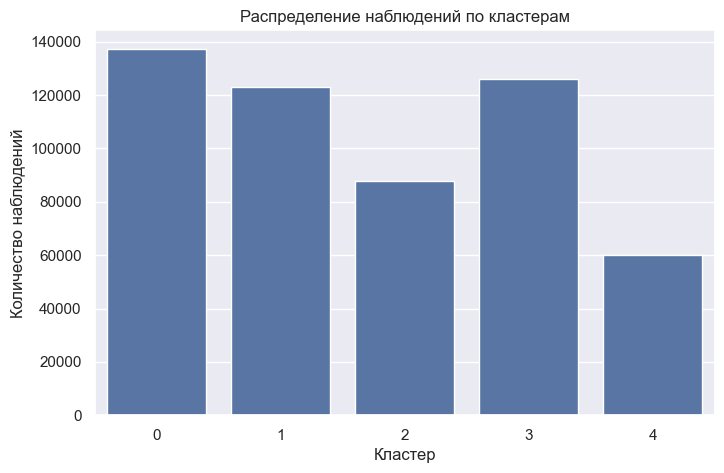

In [266]:
# Смотрим распределение объектов по кластерам

plt.figure(figsize=(8, 5))

sns.countplot(
    data=X_result,
    x='cluster',
    order=sorted(X_result['cluster'].unique())
)

plt.title('Распределение наблюдений по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Количество наблюдений')
plt.show()

In [267]:
# Выводим в процентах
cluster_distribution = (
    X_result['cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_distribution

cluster
0    25.71
1    22.98
2    16.44
3    23.60
4    11.26
Name: proportion, dtype: float64

## Вывод по распределению кластеров

Распределение получилось сбалансированным:

- кластер `0` содержит больше всего наблюдений ~25.7%
- кластер `3` и кластер `1` также занимают значительную долю ~23.6% и ~23.0%
- кластер `2` содержит ~16.4% наблюдений
- кластер `4` самый маленький ~11.3%

Таким образом, ни один кластер не оказался пустым, значит выбранное количество кластеров выглядит корректным.

# Посмотрим, как кластеры распределены по пользователям subject_id

In [268]:
# Добавляем subject_id обратно для анализа
X_result_with_subject = X_result.copy()
X_result_with_subject['subject_id'] = subject_ids

# Смотрим распределение кластеров по пользователям
subject_cluster_table = pd.crosstab(
    X_result_with_subject['subject_id'],
    X_result_with_subject['cluster'],
    normalize='index'
).mul(100).round(2)

subject_cluster_table

cluster,0,1,2,3,4
subject_id,,,,,
1,0.39,0.00,15.08,3.04,81.48
2,24.80,25.77,15.66,33.26,0.51
3,16.85,14.03,19.86,49.26,0.00
4,34.85,16.72,17.06,31.36,0.00
5,33.26,30.70,14.23,21.46,0.35
6,29.07,32.57,15.73,19.08,3.55
7,27.24,18.35,19.61,34.55,0.25
8,36.40,40.56,15.93,7.10,0.00


## Вывод по распределению кластеров по пользователям

- У пользователя `1` почти все наблюдения попали в кластер `4` ~ 81.5%
- У пользователей `3`, `4` и `7` больше всего кластер `3`
- У пользователей `6` и `8` чаще встречается кластер `1`
- Кластеры `0`, `1`, `2`, `3` встречаются у всех пользователей
- Кластер `4` сильно выражен почти только у пользователя `1`

Таким образом, наблюдается зависимость от индивидуальных особенностей пользователей или особенностей записи датчиков.
Удалив полностью `subject_id` удалось избежать переобучения.

# Финальная интерпретация кластеров

In [269]:
# Добавляем человекочитаемые названия кластеров по уровню активности

cluster_names = {
    0: 'низкая активность',
    1: 'средняя активность',
    2: 'средняя активность',
    3: 'высокая активность',
    4: 'самая высокая активность'
}

X_result['cluster_name'] = X_result['cluster'].map(cluster_names)

# Проверяем результат
X_result[['cluster', 'cluster_name']].head()

,cluster,cluster_name
0,2,средняя активность
1,0,низкая активность
2,1,средняя активность
3,1,средняя активность
4,3,высокая активность


# Распределение по уровням активности

In [270]:
# Смотрим распределение наблюдений по текстовым группам активности

activity_distribution = (
    X_result['cluster_name']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

activity_distribution.columns = ['activity_group', 'proportion']

activity_distribution

,activity_group,proportion
0,средняя активность,39.43
1,низкая активность,25.71
2,высокая активность,23.60
3,самая высокая активность,11.26


## Вывод по интерпретации кластеров

На основе ускорения кластеры были интерпретированы как группы с разным уровнем физической активности.

Определить точные названия реальных действий (ходьба, бег или отдых) не представляется возможным, так как данные в датасете не размечены.
Однако, он позволяет описать найденные группы через интенсивность движения.

Кластеризация показала, что алгоритм смог разделить наблюдения на несколько уровней активности от низкой до самой высокой.

In [271]:
# Финальная проверка итогового датасета
print(f'Итоговый размер датасета: {X_result.shape}')
print(f'Количество кластеров: {X_result['cluster'].nunique()}')
print(f'Количество групп активности: {X_result['cluster_name'].nunique()}')

X_result[
    [
        'timestamp',
        'subject_id',
        'cluster',
        'cluster_name'
    ]
].head()

Итоговый размер датасета: (534601, 55)
Количество кластеров: 5
Количество групп активности: 4


,timestamp,subject_id,cluster,cluster_name
0,252.75,5,2,средняя активность
1,3652.45,2,0,низкая активность
2,504.76,8,1,средняя активность
3,2801.61,2,1,средняя активность
4,441.01,6,3,высокая активность


# Сохранение результата

In [272]:
# Сохраняем итоговый датасет с результатами кластеризации
output_path = 'data/Physical_Activity_Monitoring_clustered.csv'

X_result.to_csv(output_path, index=False)

print(f'Файл сохранен: {output_path}')
print(f'Размер сохраненного датасета: {X_result.shape}')

Файл сохранен: data/Physical_Activity_Monitoring_clustered.csv
Размер сохраненного датасета: (534601, 55)


## Пояснение по итоговой интерпретации кластеров

Финальная проверка показала, что после кластеризации в датасете осталось 5 кластеров (`0`, `1`, `2`, `3`, `4`).

При интерпретации результатов два кластера были объединены в одну смысловую группу **средняя активность**.
Это связано с тем, что кластеры `1` и `2` близки друг к другу по агрегированным признакам (по среднему ускорению `mean_acc`),
поэтому будем считать их схожими по активности.

В результате итоговая интерпретация выглядит так:

- кластер `0` -> **низкая активность**
- кластеры `1` и `2` -> **средняя активность**
- кластер `3` -> **высокая активность**
- кластер `4` -> **самая высокая активность**

Модель выделила 5 технических кластеров, но для более понятной интерпретации они были сведены до 4-х смысловых групп активности.

Итоговый датасет `X_result` содержит:

- исходные признаки датчиков
- идентификатор пользователя `subject_id`
- номер кластера `cluster`
- человекочитаемое название группы активности `cluster_name`

# Формируем файл для Kaggle

In [273]:
# Создаем преобразование номеров кластеров в последовательные activityID

# Сортируем кластеры по уровню активности от низкой к высокой
cluster_order = (
    cluster_profile
    .sort_values('mean_acc')
    ['cluster']
    .tolist()
)

# Создаем mapping
# исходный cluster -> activityID
cluster_mapping = {
    cluster: activity_id
    for activity_id, cluster in enumerate(cluster_order, start=1)
}

cluster_mapping

{0: 1, 2: 2, 1: 3, 3: 4, 4: 5}

In [274]:
# Собираем файл для Kaggle
submission = pd.DataFrame({
    'Index': range(len(X_result)),
    'activityID': X_result['cluster'].map(cluster_mapping)
})

# Проверяем размер и первые строки
print(f'Submission shape: {submission.shape}')
print(f'Количество уникальных activityID: {submission['activityID'].nunique()}')

submission.head()

Submission shape: (534601, 2)
Количество уникальных activityID: 5


,Index,activityID
0,0,2
1,1,1
2,2,3
3,3,3
4,4,4


In [275]:
# Финальная проверка submission перед сохранением
print(f'Размер submission: {submission.shape}')
print(f'Мин index: {submission['Index'].min()}')
print(f'Макс index: {submission['Index'].max()}')
print(f'Мин activityID: {submission['activityID'].min()}')
print(f'Макс activityID: {submission['activityID'].max()}')
print(f'Пропуски: {submission.isna().sum().sum()}')

# Сохраняем файл для Kaggle
submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f'Файл сохранен: {submission_path}')

Размер submission: (534601, 2)
Мин index: 0
Макс index: 534600
Мин activityID: 1
Макс activityID: 5
Пропуски: 0
Файл сохранен: submission.csv


In [276]:
# Проверяем первые строки сохраненного файла
pd.read_csv('submission.csv').head()

,Index,activityID
0,0,2
1,1,1
2,2,3
3,3,3
4,4,4


## Итоговая отправка на Kaggle

Файл `submission.csv` сформирован согласно требованиям и загружен на Kaggle:

- `Index` -> индекс наблюдения
- `activityID` -> преобразованный номер кластера в последовательную нумерацию активности

Полученные значения на Kaggle после автоматизированной оценки результата:
- Public Score: `0.07194`
- Private Score: `0.07145`